In [1]:
%matplotlib inline

import matplotlib
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

/home/leo/.local/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Define desintegration constants (check correction factors)
lambda_230 = 0.0000091577 * 1.0014
lambda_232 = 0.000000000049475
lambda_234 = 0.0000028263 * 0.9985
lambda_238 = 0.000000000155125

# Atomic masses of U and Th isotopes (IUPAC 2019)
U_atom = 238.028913
U234_atom = 234.040950
U235_atom = 235.043928
U238_atom = 238.050785

Th_atom = 232.03774
Th230_atom = 230.033132
#Th232_atom = 232.038054
Th232_atom = 232.032

# Secular equilibrium 230/232 initial ratio (ref?)
Th230_Th232_ini = 0.0000044

In [26]:
def calc_Th230_U238_act(d234U, T):
    ''' Function that calculates 230Th/238U activity ratios from delta234U
    measured and age (years)'''
    
    # Compute first initial d234U_0
    d234U_ini = d234U * np.e**(lambda_234 * T)
    
    # Compute different terms in age equation (closed system)
    term_1 = np.e**(-lambda_230 * T)
    term_2 = lambda_230 / (lambda_230 - lambda_234)
    term_3 = 1 - np.e**((lambda_234 - lambda_230) * T)
    
    # Compute final solution
    solution = (term_1 - (d234U/1000 * term_2 * term_3) - 1) * -1
    
    #return solution
    return solution


def age_calc_Th230_U238_CS(T_ini, m_Th230_U238_a, m_d234U, diff = 0.0001):
    ''' Function that iterates times until computed U/Th activity is close 
    enough to measured U/Th activity based on preset threshold'''
    
    # Compute initial 230Th_238U activity estimate
    Th230_238U_a_estim = calc_Th230_U238_act(m_d234U, T_ini)
    
    # Loop until condition diference in activity ratios measured and estimated
    # is below threshold
    
    T_cal = T_ini
    
    while abs(Th230_238U_a_estim - m_Th230_U238_a) > diff:
        if (Th230_238U_a_estim - m_Th230_U238_a) <= 0:
            T_cal = T_cal + 1
        else:
            T_cal = T_cal - 1

        # Compute ratio estimate with new age to change condition
        if T_cal >= 700000:
            return 0
        Th230_238U_a_estim = calc_Th230_U238_act(m_d234U, T_cal)
                
    # Return age in years
    return T_cal

def init_230_232Th_a(measured_ratio, age):
    '''Calculate intitial 230/232 activity ratio from measured and age estimate'''
    
    return measured_ratio * np.e**(-lambda_230 * age)


def m_Th230_U238_a_from_concs(Th230_pmolg, U238_ppb):
    '''From ID estimated concs calculate measured activity ratio'''
    
    Th230_U238_atom = (Th230_pmolg / (U238_ppb / U238_atom)) / 1000
    
    return Th230_U238_atom * lambda_230 / lambda_238

In [61]:
Th230U238_A = np.arange(0, 2.5, 0.05)
delta234U_m = np.arange(0, 4000, 5)
time = np.arange(0, 600000, 2)

In [39]:
# Create empty array for storing data
C = [[0 for col in range(len(Th230U238_A))] for row in range(len(delta234U_m))]

In [40]:
# Iterate over x and y to populate arrays
for i, id_i in tqdm(zip(Th230U238_A, range(len(Th230U238_A))), total=len(Th230U238_A)):
    for j, id_j in zip(delta234U_m, range(len(delta234U_m))):
        if id_j == 0:
            C[id_j][id_i] = age_calc_Th230_U238_CS(0, i, j)
        else:
            C[id_j][id_i] = age_calc_Th230_U238_CS(C[id_j-1][id_i], i, j)
        #print(i, j, C[id_j][id_i])
        

100%|████████████████████████████████████████| 50/50 [1:26:50<00:00, 104.21s/it]


In [54]:
# 234U_m to iterate for isolines
#iter_234U_m = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000]
iter_234U_m = np.arange(0, 4000, 10)

# Time vector
#time = np.arange(0, 700000, 10)

# List of lists to store results
res_final = []
delt_final = []

# Iterate over 234U and time

for i, id_i in tqdm(zip(iter_234U_m, range(len(iter_234U_m)))):
    res_f = []
    delt_f = []
    tmp = i * np.e**(-lambda_234 * time)
    delt_final.append(tmp.copy())
    res_final.append(calc_Th230_U238_act(tmp.copy(), time))
        
    #res_final.append(res_f)
    #delt_final.append(delt_f)
    #print(id_i)
                    
#plt.plot(dat)
#plt.plot(res_final)

400it [00:11, 33.67it/s]


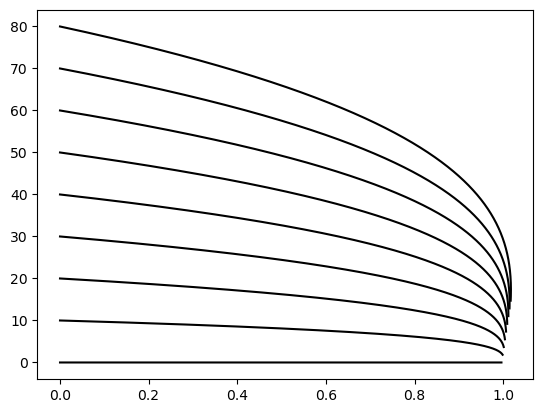

In [55]:
plt.plot(res_final[0], delt_final[0], 'k')
plt.plot(res_final[1], delt_final[1], 'k')
plt.plot(res_final[2], delt_final[2], 'k')
plt.plot(res_final[3], delt_final[3], 'k')
plt.plot(res_final[4], delt_final[4], 'k')
plt.plot(res_final[5], delt_final[5], 'k')
plt.plot(res_final[6], delt_final[6], 'k')
plt.plot(res_final[7], delt_final[7], 'k')
plt.plot(res_final[8], delt_final[8], 'k')

In [60]:
X, Y = np.meshgrid(Th230U238_A.copy(), delta234U_m.copy())
l = [[np.nan if x == 0 else x for x in C[j]] for j in range(len(X))]

<a list of 4 text.Text objects>

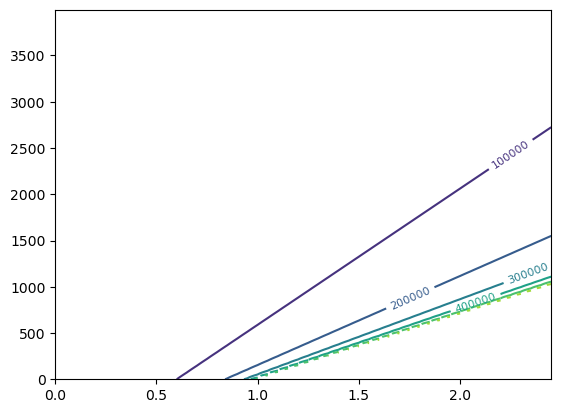

In [64]:
a=plt.contour(X,Y,l)

plt.clabel(a, inline=True, fontsize=8)

In [91]:
import pandas as pd
import hickle as hkl

In [96]:
hkl.dump(res_final, 'Th230_U238_act_isolines.hkl')
hkl.dump(delt_final, 'd234U_measured_isolines.hkl')
hkl.dump(l, 'age_isolines.hkl')

In [94]:
data2 = hkl.load('Th230_U238_act_isolines.hkl')